In [1]:
import datetime as dt
import matplotlib.patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import readsav



C:\Users\Local Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
def convert_to_datetime(row):
    return dt.datetime.strptime(
        f"{row['Yearcross']} {row['DOYcross']} {row['Hourcross']} {row['Minutecross']}",
        "%Y %j %H %M",
    )

In [3]:
#Load LFE data, compression proxy data

# Load crossing data (includes Cassini location and boundary inferred dynamic pressure)
#***to add metric to calculate MP crossing inferred DP - currently set as placeholder of 567.0 for all MP crossings
crossings_data = pd.read_csv("./cassini_crossing_list_with_trajectory_DP.txt")

# Load LFE detections
#lfe_data = pd.read_csv('../data/calculated/LFEs_joined.csv', parse_dates=['start','end'])

joined_lfes_fp = '../data/calculated/Joined_LFEs_w_phases.csv'

# Import lfe data and clear nans
lfes = pd.read_csv(joined_lfes_fp, usecols=['start', 'end', 'duration', 'subLST', 'subLat', 'R_ksm', 'x_ksm', 'y_ksm', 'z_ksm', 'north phase', 'south phase'])
lfes = lfes.dropna().reset_index(drop=True)



In [4]:
def select_lfes(lfes, subLST_cond=None, duration_cond=None, subLat_cond=None):

    selected_lfes=lfes.copy()
    
    filter_by_subLST=False
    filter_by_duration=False
    filter_by_subLaT=False
    
    if subLST_cond is not None:
        filter_by_subLST=True
        
    if duration_cond is not None:
        filter_by_duration=True

    if subLat_cond is not None:
        filter_by_subLat=True

    if filter_by_duration is True:
        duration_min, duration_max = duration_cond
        selected_lfes = selected_lfes[(duration_min <= selected_lfes['duration']) & (selected_lfes['duration'] < duration_max)]

    if filter_by_subLST is True:
        subLST_min, subLST_max = subLST_cond
        if subLST_max < subLST_min:  #over midnight boundary
            selected_lfes = selected_lfes[(subLST_min <= selected_lfes['subLST']) | (selected_lfes['subLST'] < subLST_max)]  #or statement
        else:
            selected_lfes = selected_lfes[(subLST_min <= selected_lfes['subLST']) & (selected_lfes['subLST'] < subLST_max)]
        
    return selected_lfes

In [5]:
#Sort #1 - LFEs with start time observed while Cassini between 07-11 hr LT
selected_lfes = select_lfes(lfes, subLST_cond=(7, 11)) # LFEs at dawn
LFEs_LT0711 = selected_lfes
print(len(LFEs_LT0711))

selected_lfes = select_lfes(lfes, subLST_cond=(7, 11), duration_cond=(11*3600,lfes['duration'].max()+1)) # Long LFEs at dawn
LFEs_LT0711_Long = selected_lfes
print(len(LFEs_LT0711_Long))

selected_lfes = select_lfes(lfes, subLST_cond=(7, 11), duration_cond=(lfes['duration'].min(), 11*3600)) # Short LFEs at dawn
LFEs_LT0711_Short = selected_lfes
print(len(LFEs_LT0711_Short))


887
165
722


C:\Users\Local Admin\AppData\Local\Temp\ipykernel_15272\3475935006.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BS_crossings_allDP["crossing_time"] = BS_crossings_allDP.apply(convert_to_datetime, axis=1)


1249
median and mean of inferred Dp for BS crossings is: 
0.030839914417274 0.0550999647747698
134 matched LFEs for 07-11 all
96 matched LFEs for 07-11 Short
median and mean of inferred Dp for Short LFEs 07-11 hr LT is: 
0.02351136639505205 0.03524430987772814 0.034709587299303235
38 matched LFEs for 07-11 Long
median and mean of inferred Dp for Long LFEs 07-11 hr LT is: 
0.032097405362434 0.042574893631991385 0.033404351270977045


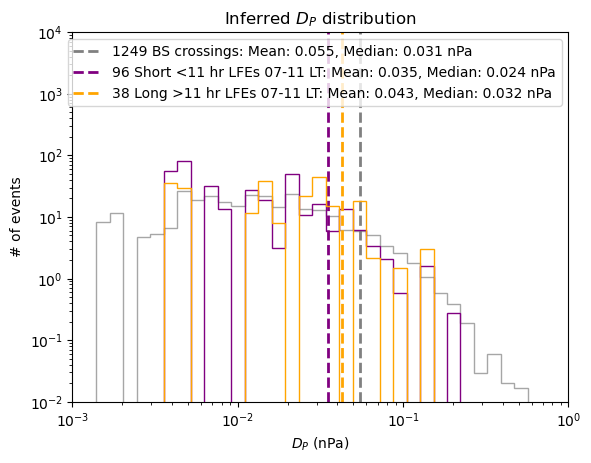

In [15]:
##########Now determine "compression arrival proxies"############################

#Compression arrival proxy #1 = BS crossings with inferred DP in tail of distribution
#BS_crossings_highDP = crossings_data.loc[(crossings_data["Typecross"] == "BS") & (crossings_data["inf_DP"] > 0.1)]#and DP gt threshold
#BS_crossings_highDP["crossing_time"] = BS_crossings_highDP.apply(convert_to_datetime, axis=1)

BS_crossings_allDP = crossings_data.loc[(crossings_data["Typecross"] == "BS")]
BS_crossings_allDP["crossing_time"] = BS_crossings_allDP.apply(convert_to_datetime, axis=1)

#comparison_metric = BS_crossings_highDP["crossing_time"]
#compression_proxy_times = BS_crossings_highDP["crossing_time"]

#Plot distribution of All inferred DP (from BS crossings - thomsen data to follow)
fix,ax=plt.subplots()
nbins=50
bins=np.logspace(np.log10(0.0001),np.log10(1), nbins)
ax.hist(BS_crossings_allDP["inf_DP"],bins=bins,color='grey',density=True,alpha=0.7,histtype="step")
ax.set_xlabel("$D_P$ (nPa)")
ax.set_ylabel("# of events")
ax.set_yscale('log')
#ax.set_ylim([1e0,5e2]) #for when we don't set density=True
ax.set_ylim([1e-2,1e4]) #for when we set density=True to give a normalised histogram
ax.set_xscale('log')
ax.set_xlim([1e-3,1e0])
ax.set_title('Inferred $D_P$ distribution')

median_dp_AllBS = np.median(np.array(BS_crossings_allDP["inf_DP"])) 
mean_dp_AllBS = np.mean(np.array(BS_crossings_allDP["inf_DP"]))  
print(len(BS_crossings_allDP))
print('median and mean of inferred Dp for BS crossings is: ')
print(median_dp_AllBS, mean_dp_AllBS)
ax.axvline(x=mean_dp_AllBS, linewidth=2, linestyle="dashed", label=f"{len(BS_crossings_allDP):.0f} BS crossings: Mean: {mean_dp_AllBS:.3f}, Median: {median_dp_AllBS:.3f} nPa",color='grey')
#Do I want to have a separate vertical line for the medians?

#This block doesn't work as this BS crossing file doesn't have local times. Need to find another or calculate!
#BS_crossings_allDP_0711 = crossings_data.loc[(crossings_data["Typecross"] == "BS") & (crossings_data['localtime'] >7) & (crossings_data['localtime'] <11)]
#BS_crossings_allDP_0711["crossing_time"] = BS_crossings_allDP_0711.apply(convert_to_datetime, axis=1)
#ax.hist(BS_crossings_allDP_0711["inf_DP"],bins=bins,color='green')
#median_dp_AllBS_0711 = np.median(np.array(BS_crossings_allDP_0711["inf_DP"])) 
#mean_dp_AllBS_0711 = np.mean(np.array(BS_crossings_allDP_0711["inf_DP"]))     
#print('median and mean of inferred Dp for BS crossings 07-11 is: ')
#print(median_dp_AllBS_0711, mean_dp_AllBS_0711)
#ax.axvline(x=mean_dp_AllBS_0711, linewidth=2, linestyle="dashed", label=f"Mean (all BS 07-11): {mean_dp_AllBS_0711:.3f} nPa",color='green')



#overplot distribution of DP *near* LFEs that are observed between 07-11 hr LT
# For each BS/MP crossing with inferred DP, find the closest following LFE
#First search near the LFEs that are seen between LT of 07-11 hrs

lfe_match_window = dt.timedelta(hours=50)  #this can be adjusted to search over any window size
matched_events = []

for _, LFErow in LFEs_LT0711.iterrows():

    crossing_times = pd.to_datetime(BS_crossings_allDP["crossing_time"])
    lfe_start = pd.to_datetime(LFErow["start"])

    # negative is crossing is before LFE, positive if crossing is after LFE
    time_differences = crossing_times - lfe_start
    
    #Yesprint(time_differences)

    # We are only interested in the crossings prior to the LFE
    time_differences = time_differences[time_differences < dt.timedelta(0)]

    if len(time_differences) ==0:
        continue
    
    # The closest crossing to the LFE is the one with the smallest time difference
    closest_crossing_index = time_differences.idxmax()
    closest_crossing_time_difference = time_differences[closest_crossing_index]

    # The event is a match if the time difference is less than our matching window
    if abs(closest_crossing_time_difference) <= lfe_match_window:
        matched_events.append(
            {
                "LFE": LFErow,  # This LFE
                "Crossing": BS_crossings_allDP.loc[
                    closest_crossing_index
                ],  # The matching crossing
            }
        )

    else:
        continue

print(f"{len(matched_events)} matched LFEs for 07-11 all")
dp=[]
for event in matched_events:
    dp.append(event["Crossing"]["inf_DP"])
 
##Comment out printing the "All" LFEs as just split into short and long only
#ax.hist(dp,bins=bins,color='blue')
#median_dp = np.median(np.array(dp)) 
#mean_dp = np.mean(np.array(dp))     
 
#print('median and mean of inferred Dp for All LFEs 07-11 hr LT is: ')
#print(median_dp, mean_dp)

#ax.axvline(x=mean_dp, linewidth=2, linestyle="dashed", label=f"Mean (all LFEs 07-11 LT): {mean_dp:.3f} nPa",color='blue')

#Second search near the LFEs that are seen between LT of 07-11 hours AND that have short duration
matched_events_Short = []

for _, LFErow_Short in LFEs_LT0711_Short.iterrows():

    crossing_times = pd.to_datetime(BS_crossings_allDP["crossing_time"])
    lfe_start = pd.to_datetime(LFErow_Short["start"])

    # negative is crossing is before LFE, positive if crossing is after LFE
    time_differences = crossing_times - lfe_start
    
    #Yesprint(time_differences)

    # We are only interested in the crossings prior to the LFE
    time_differences = time_differences[time_differences < dt.timedelta(0)]

    if len(time_differences) ==0:
        continue
    
    # The closest crossing to the LFE is the one with the smallest time difference
    closest_crossing_index = time_differences.idxmax()
    closest_crossing_time_difference = time_differences[closest_crossing_index]

    # The event is a match if the time difference is less than our matching window
    if abs(closest_crossing_time_difference) <= lfe_match_window:
        matched_events_Short.append(
            {
                "LFE": LFErow_Short,  # This LFE
                "Crossing": BS_crossings_allDP.loc[
                    closest_crossing_index
                ],  # The matching crossing
            }
        )

    else:
        continue

print(f"{len(matched_events_Short)} matched LFEs for 07-11 Short")
dp_Short=[]
for event in matched_events_Short:
    dp_Short.append(event["Crossing"]["inf_DP"])
    
ax.hist(dp_Short,bins=bins,color='purple',density=True,histtype="step")
median_dp_Short = np.median(np.array(dp_Short)) 
mean_dp_Short = np.mean(np.array(dp_Short))   
stdev_dp_Short = np.std(np.array(dp_Short))
 
print('median and mean of inferred Dp for Short LFEs 07-11 hr LT is: ')
print(median_dp_Short, mean_dp_Short, stdev_dp_Short)
      
#ax.axvline(x=mean_dp_Short, linewidth=2, linestyle="dashed", label=f"Mean (all Short (< 11 hr) LFEs 07-11 LT): {mean_dp_Short:.3f} nPa",color='purple')
ax.axvline(x=mean_dp_Short, linewidth=2, linestyle="dashed", label=f"{len(dp_Short):.0f} Short <11 hr LFEs 07-11 LT: Mean: {mean_dp_Short:.3f}, Median: {median_dp_Short:.3f} nPa",color='purple')


#Third search near the LFEs that are seen between LT of 07-11 hrs AND that have long duration

matched_events_Long = []

for _, LFErow_Long in LFEs_LT0711_Long.iterrows():

    crossing_times = pd.to_datetime(BS_crossings_allDP["crossing_time"])
    lfe_start = pd.to_datetime(LFErow_Long["start"])

    # negative is crossing is before LFE, positive if crossing is after LFE
    time_differences = crossing_times - lfe_start
    
    #Yesprint(time_differences)

    # We are only interested in the crossings prior to the LFE
    time_differences = time_differences[time_differences < dt.timedelta(0)]

    if len(time_differences) ==0:
        continue
    
    # The closest crossing to the LFE is the one with the smallest time difference
    closest_crossing_index = time_differences.idxmax()
    closest_crossing_time_difference = time_differences[closest_crossing_index]

    # The event is a match if the time difference is less than our matching window
    if abs(closest_crossing_time_difference) <= lfe_match_window:
        matched_events_Long.append(
            {
                "LFE": LFErow_Long,  # This LFE
                "Crossing": BS_crossings_allDP.loc[
                    closest_crossing_index
                ],  # The matching crossing
            }
        )

    else:
        continue

print(f"{len(matched_events_Long)} matched LFEs for 07-11 Long")
dp_Long=[]
for event in matched_events_Long:
    dp_Long.append(event["Crossing"]["inf_DP"])
    
ax.hist(dp_Long,bins=bins,color='orange',density=True,histtype="step")
median_dp_Long = np.median(np.array(dp_Long)) 
mean_dp_Long = np.mean(np.array(dp_Long)) 
stdev_dp_Long= np.std(np.array(dp_Long))
 
print('median and mean of inferred Dp for Long LFEs 07-11 hr LT is: ')
print(median_dp_Long, mean_dp_Long,stdev_dp_Long)
      
#ax.axvline(x=mean_dp_Long, linewidth=2, linestyle="dashed", label=f"Mean (all Long (> 11 hr) LFEs 07-11 LT): {mean_dp_Long:.3f} nPa",color='orange')
ax.axvline(x=mean_dp_Long, linewidth=2, linestyle="dashed", label=f"{len(dp_Long):.0f} Long >11 hr LFEs 07-11 LT: Mean: {mean_dp_Long:.3f}, Median: {median_dp_Long:.3f} nPa",color='orange')



plt.legend()

plt.savefig("Inferred_Dp_dist.pdf",format="pdf")
plt.show()

#print(dp)
#count=0

#for i,LFErow in LFEs_LT0711.iterrows():
#    count=count+1
##    for j,BSrow in BS_crossings_allDP.iterrows():
#        #determine time difference between this and LFE start time
#    timediff=pd.to_datetime(BS_crossings_allDP["crossing_time"])-pd.to_datetime(LFErow["start"])  #negative is crossing is before LFE, positive if crossing is after LFE
           
#print(count)


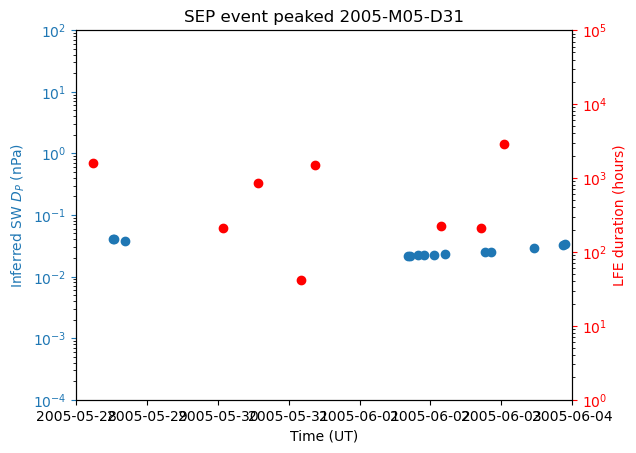

In [4]:

#Compression arrival proxy #2 = Arrival/Peak of SEP Event (46 examples from Roussos et al 2017 paper)
#Load SEP event times
SEP_data = pd.read_csv("./SEP_events_table.csv")
#print(SEP_data["Peak Time"])


#Compression arrival proxy #3 = Arrival of ICMEs (from ICMECat) ***to download a csv of these


fix,ax=plt.subplots()
ax.scatter(BS_crossings_allDP["crossing_time"],BS_crossings_allDP["inf_DP"])
ax.set_xlim(dt.datetime(2005,5,28),dt.datetime(2005,6,4))
ax.set_xlabel("Time (UT)")
ax.set_ylabel("Inferred SW $D_P$ (nPa)")
ax.yaxis.label.set_color('C0')
ax.tick_params(axis='y', colors='C0')
ax.set_yscale('log')
ax.set_ylim([1e-4,1e2])
ax.set_title('SEP event peaked 2005-M05-D31')
   

#ax.scatter(BS_crossings_highDP["crossing_time"],BS_crossings_highDP["inf_DP"])

lfe_axis=ax.twinx()
lfe_axis.scatter(lfe_data["start"],lfe_data["duration"]/60.,color="red")
lfe_axis.set_ylabel("LFE duration (hours)")
lfe_axis.yaxis.label.set_color('red')    
lfe_axis.tick_params(axis='y', colors='red')
lfe_axis.set_yscale('log')
lfe_axis.set_ylim([1e0,1e5])
#Consider different colour markers for short and long LFEs?

#ax.axvline(x="2004-08-26 01:00", color="black", linewidth=2, label=f"SEP event 2004 239 01:00") Figure out how to plot this!

#print(BS_crossings_highDP["crossing_time"].tolist())
#print(BS_crossings_highDP["inf_DP"])

plt.savefig("SW_Compression_SEP_M05_D31_Y05.pdf",format="pdf")
plt.show()

In [5]:
#def compare_LFEs_compressions(comparison_metric):
def compare_LFEs_compressions(compression_proxy_times,lfe_data):

    # We want to compare all LFEs with all compression times to produce a list
    # of LFE time differences of length:
    # len(comparison_metric) * len(lfe_start_times)

    # compression_proxy_times should be an iterable of datetime objects.
    all_lfe_time_deltas = []
    
   # print(lfe_start_times)
   # print("checking types of arrays")
   # print(comparison_time)
  
    #compression_proxy_times=np.array([np.datetime64(time) for time in compression_proxy_times])
    #lfe_start_times=np.array([np.datetime64(time) for time in lfe_start_times])
    
    #comparison_time = np.datetime64(comparison_time)
    
    
    for comparison_time in compression_proxy_times:

        # Maybe it is more appropriate to use the middle time of the LFE -
        # especially to investigate any skews. This would be relevant if LFE
        # durations are comparable to the spread of the distribution.
        
        
        #print(type(comparison_time))
        #print(type(lfe_start_times[0]))
        #print(comparison_time.dtype)
        #print(lfe_start_times[0].dtype)
        #comparison_time = np.datetime64(comparison_time)
        
        current_proxy_lfe_deltas = lfe_data["start"] - comparison_time
       # current_proxy_lfe_deltas = lfe_start_times - comparison_time

        all_lfe_time_deltas.extend(current_proxy_lfe_deltas)
        
        #blah=1/0.
    # Convert to some numerical value, here is hours
    all_lfe_time_deltas = [
        delta.total_seconds() / 3600 for delta in all_lfe_time_deltas
    ]

    
    
    # Returns a list of datetime timedelta objects
    return all_lfe_time_deltas



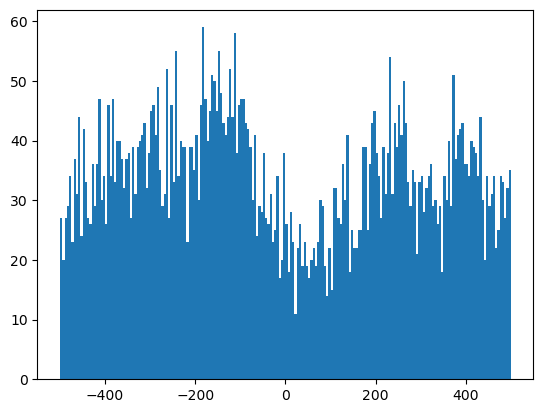

In [6]:


# Some sample plotting code for one compression proxy.
lfe_time_deltas = compare_LFEs_compressions(BS_crossings_highDP["crossing_time"],lfe_data)

binsize=5
bins=np.arange(-500,500+binsize,binsize) #set bins 100 hours either side of the compression metric and 1 hour wide

fig, ax = plt.subplots()

ax.hist(lfe_time_deltas,bins=bins);

# Set some sane xlim bounds, these are in hours based on the
# calculation within the function.
#ax.set_xlim(-72, 72)
   


In [7]:

def calculate_bow_shock_dynamic_pressure(crossings_data):
    epsilon = 0.84
    c1 = 15
    c2 = 5.4

    saturn_radius = 60269  # km

    x_crossings = crossings_data["X_KSM(km)"]
    y_crossings = crossings_data["Y_KSM(km)"]
    z_crossings = crossings_data["Z_KSM(km)"]

    crossing_positions = np.array([x_crossings, y_crossings, z_crossings])

    r_crossings = np.sqrt(np.sum(crossing_positions**2))
    theta_crossings = np.arccos(x_crossings / r_crossings)

    tmp_a = (r_crossings / saturn_radius) * (1 + (epsilon * np.cos(theta_crossings)))
    tmp_b = (1 + epsilon) * c1

    return (tmp_a / tmp_b) ** (-c2)



In [8]:
def calculate_magnetopause_dynamic_pressure(crossings_data):
    #This needs to be fixed to give the DP for the MP crossings too!
    return [np.nan] * len(crossings_data)


In [13]:
# Load crossing data (includes Cassini location and boundary dynamic pressure)
crossings_data = pd.read_csv("./cassini_crossing_list_with_trajectory_DP.txt")

# Only include crossings were MP is followed directly by BS
mask = (crossings_data["Typecross"] == "MP") & (crossings_data["Typecross"].shift(-1) == "BS")
crossings_data = crossings_data[mask | mask.shift(1)]

bow_shock_crossings = crossings_data.loc[crossings_data["Typecross"] == "BS"]
magnetopause_crossings = crossings_data.loc[crossings_data["Typecross"] == "MP"]

bow_shock_crossings["crossing_time"] = bow_shock_crossings.apply(convert_to_datetime, axis=1)
magnetopause_crossings["crossing_time"] = magnetopause_crossings.apply(convert_to_datetime, axis=1)
bow_shock_dynamic_pressure = calculate_bow_shock_dynamic_pressure(bow_shock_crossings).tolist()#why is this needed as input file has Dp?!
magnetopause_dynamic_pressure = calculate_magnetopause_dynamic_pressure(magnetopause_crossings)#this may be needed in due course as currently MP Inf_Dp = 567.0 for all MP (placeholder)

# Load LFE detections
#lfe_data = pd.read_csv("./LFEs_joined.csv", parse_dates=["start", "end"])
lfe_data = pd.read_csv('../data/calculated/LFEs_joined.csv', parse_dates=['start','end'])

lfe_start_times = np.array(lfe_data["start"].tolist())
lfe_end_times = np.array(lfe_data["end"].tolist())

#print(lfe_start_times)
print(len(bow_shock_crossings))
#print(bow_shock_crossings)
print(len(magnetopause_crossings))

#print(magnetopause_crossings)

109
      Unnamed: 0  Yearcross  DOYcross  Hourcross  Minutecross Typecross  \
27            27       2004       189         14            5        BS   
54            54       2004       309         22           41        BS   
82            82       2004       358         20           37        BS   
94            94       2005        24          3            1        BS   
114          114       2005        55          8           46        BS   
...          ...        ...       ...        ...          ...       ...   
3356        3356       2016        78         19           26        BS   
3380        3380       2016       103          2           24        BS   
3404        3404       2016       136         16           19        BS   
3420        3420       2016       167          7           40        BS   
3442        3442       2016       191          5           16        BS   

     DIRNcross  DOYFRACcross       Timestamp(UTC)      X_KSM(km)   Y_KSM(km)  \
27           O 

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_26256\1864749609.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bow_shock_crossings["crossing_time"] = bow_shock_crossings.apply(convert_to_datetime, axis=1)
C:\Users\Local Admin\AppData\Local\Temp\ipykernel_26256\1864749609.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  magnetopause_crossings["crossing_time"] = magnetopause_crossings.apply(convert_to_datetime, axis=1)


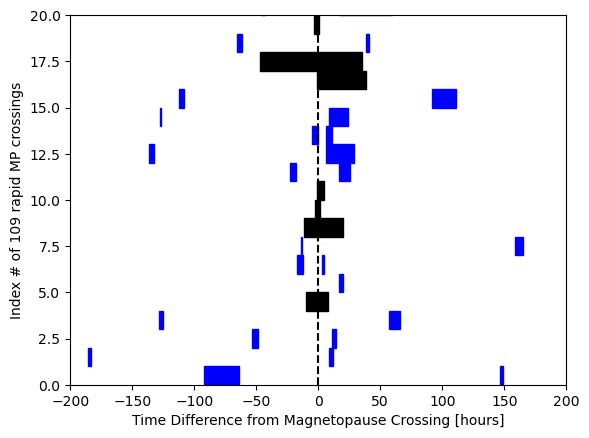

In [17]:


def main():

    
    # For each MP crossing (keep flexible as could be BS or some offset), find
    # the nearest LFE before, and the nearest LFE after.
    # Make a bar plot with time on the X axis, and some other parameter on the
    # Y axis (MP index, DP, etc.)
    comparison_lfes = []
    comparison_metric = magnetopause_crossings["crossing_time"]

    for comparison_time in comparison_metric:

        # Check if crossing_time is inside any LFE (start ≤ crossing_time ≤ end)
        inside_lfe = (
            (lfe_start_times <= comparison_time) & (lfe_end_times >= comparison_time)
        ).any()

        if not inside_lfe:
            lfe_index_before = np.searchsorted(lfe_end_times, comparison_time) - 1
            lfe_index_after = np.searchsorted(lfe_start_times, comparison_time)

            comparison_lfes.append((lfe_index_before, lfe_index_after))

        else:
            # If we are crossing during an LFE we just want to plot that one
            inside_lfe_index = np.where(
                (lfe_start_times <= comparison_time)
                & (lfe_end_times >= comparison_time)
            )[0]

            if (len(inside_lfe_index)) != 1:
                raise ValueError()

            comparison_lfes.append((inside_lfe_index))

    fig, ax = plt.subplots()

    y_values = list(range(len(magnetopause_crossings)))
    sort_by = "MP DP" # "BS DP", "MP DP", "BS DP Calc", "MP DP Calc"

    match sort_by:
        case "BS DP":
            # Bow shock DP from file
            y_values = np.argsort(bow_shock_crossings["inf_DP"])

        case "MP DP":
            # Magnetopause DP from file
            y_values = np.argsort(magnetopause_crossings["inf_DP"])

        case "BS DP Calc":
            # Bow shock DP from function
            y_values = np.argsort(bow_shock_dynamic_pressure)

        case "MP DP Calc":
            # Magnetopause DP from function
            pass

        case _:
            pass



    # Formatting
    ax.axvline(0, ymin=np.min(y_values), ymax=np.max(y_values), color="black", ls="dashed")
    #ax.set_ylim(np.min(y_values), np.max(y_values))
    ax.set_ylim(0,20)#for small number for viewing/testing
    ax.set_xlim(-200, 200)
    #ax.set_xscale('log')# for now leave it linear, but need to figure out how to show negative numbers (LFEs before) on log
    
    # Adding LFEs
    patches = []
    patch_height = 1

    for y, lfe_index_group, comparison_time in zip(y_values, comparison_lfes, comparison_metric):

        # if only 1, crossing is during an LFE
        if len(lfe_index_group) == 1:
            i = lfe_index_group[0]
            lfe_start = (lfe_start_times[i] - comparison_time).total_seconds() / 3600
            lfe_end = (lfe_end_times[i] - comparison_time).total_seconds() / 3600

            rect = matplotlib.patches.Rectangle(
                (lfe_start, y), lfe_end - lfe_start, patch_height, color="black"
            )
            patches.append(rect)

        else:
            i = lfe_index_group[0]

            lfe_start = (lfe_start_times[i] - comparison_time).total_seconds() / 3600
            lfe_end = (lfe_end_times[i] - comparison_time).total_seconds() / 3600

            rect = matplotlib.patches.Rectangle(
                (lfe_start, y), lfe_end - lfe_start, patch_height, color="blue"
            )
            patches.append(rect)

            i = lfe_index_group[1]

            lfe_start = (lfe_start_times[i] - comparison_time).total_seconds() / 3600
            lfe_end = (lfe_end_times[i] - comparison_time).total_seconds() / 3600

            rect = matplotlib.patches.Rectangle(
                (lfe_start, y), lfe_end - lfe_start, patch_height, color="blue"
            )
            patches.append(rect)

    [ax.add_patch(p) for p in patches]

    ax.set_xlabel("Time Difference from Magnetopause Crossing [hours]")
    ax.set_ylabel("Index # of 109 rapid MP crossings")
    

    plt.show()




if __name__ == "__main__":
    main()
